# Log-Space Neural Networks in Keras

This notebook presents a custom TensorFlow (TF)/Keras-compatible implementation of the dense/fully connected multilayer model where computations are performed in the **logarithmic domain** using LNS (Logarithmic Number System) arithmetic and the XLNS library.

This includes:
- Basic log-space arithmetic functions for tf.Tensors (addition, subtraction, multiplication, division, and Matrix Multiplication )
- A custom `LogSpaceDense` layer compatible with `tf.keras`
- A custom `LogSpaceSGD` optimizer
- Training and benchmarking this model on linear and non-linear functions (e.g., `y = 2x`, `x²`, `sin(x)`)
- Comparisons with standard `Dense` layers from Keras

The aim is to explore the benefits of the possibility of training deep models in log-space while remaining compatible with TF/Keras.


In [1]:
import tensorflow as tf
import numpy as np
import math
import matplotlib.pyplot as plt


In [2]:
pip install xlns

In [3]:
import xlns as xl

## Precision Settings
In this notebook, the TF backend is configured to operate using **float64** tensors, since xlns uses int64 encoding of scaled LNS representation of fp numbers, and it was observed that these numbers when converted to the default **float32** format would lose some precision crucial for determining their sign (using the last digit).

Furthermore, the notebook currently implements the fully-connected model eagerly and benchmarks it with eager keras dense models, however, some provisions have been made to support symbolic execution as well.

In [4]:
tf.keras.backend.set_floatx('float64')

In [5]:
tf.keras.config.floatx()

'float64'

In [6]:
tf.config.run_functions_eagerly(True)

## Log-Space Arithmetic Functions

Although already defined in the xlns library, due to incompatibility with TF tensors, the notebook defines basic arithmetic operations that operate in the **logarithmic number system** that facilitate all forward and backward passes in the log-space neural network.

These include:
- Log-domain addition (`lns_add_int64`)
- Subtraction (`lns_sub_int64`)
- Multiplication (`lns_mul_int64`)
- Division (`lns_div_int64`)
- Matrix multiplication using LNS (`lns_matmul_int64`)


In [7]:
def lns_to_float(x_data):
    """Converts tensors in LNS representation to float."""
    x = x_data // 2 #Getting the log magnitude
    s = x_data % 2 #the sign bit

    x_float = tf.pow(2.0, tf.cast(x, tf.float64) / (2**23))  #opposite shifting
    x_float = tf.where(tf.equal(s, 1), -x_float, x_float)

    return tf.cast(x_float,tf.float64)
def sbdb_ufunc_ideal2(x, sign_bit):
    """Helper function for obataining addition/subtraction correction term"""

    correction=tf.cast((((tf.math.log(tf.abs(1-2*tf.cast(sign_bit,tf.float64) +tf.pow(tf.cast(2.0,dtype=tf.float64),tf.cast((x/2**23),tf.float64))))/tf.math.log(tf.cast(2.0,tf.float64))))*2**23),tf.int64)*2 #+ tf.cast(sign_bit, tf.int64)#why adding sign_bit?? if sb==1 do substraction

    return correction

In [8]:
@tf.custom_gradient
def lns_add_int64(x, y):
    """Addition of of 2 log-domain numbers using helper function sbdb_ufunc_ideal2"""




    y=tf.cast(y,tf.int64)
    x=tf.cast(x,tf.int64)

    max_part = tf.maximum(x, y)
    sign_bit_x=x%2
    sign_bit_y=y%2


    delta = -tf.abs((x // 2) - (y // 2))
    sign_bit = (x ^ y) & 1



    correction = sbdb_ufunc_ideal2(delta, sign_bit)

    result= tf.convert_to_tensor(tf.cast(max_part + tf.cast(correction,tf.int64),tf.float64))
    result = tf.where(
    tf.logical_and(tf.equal(x//2-y//2, 0), tf.equal(sign_bit, 1)),  # Condition for 0 handling
    tf.constant(-9223372036854775808, dtype=tf.float64),
    result
)


    def grad(dy,variables=None):
        """Gradients are returned with respect to each input"""


        return  dy,dy


    return result, grad

@tf.custom_gradient
def lns_sub_int64(x, y):
    """Subtracts two lns numbers"""
    x=tf.cast(x,tf.int64)
    y=tf.cast(y,tf.int64)
    result = lns_add_int64(x,y^1)  # Forward pass

    def grad(dy,variables=None):
        """Gradients are returned with respect to each input"""

        return dy, tf.cast(tf.cast(dy,tf.int64)^1,tf.float64)


    return result, grad



In [9]:
def lns_mul_int64(x, y):
    """Returns multiplication result of two numbers in LNS representation by simply adding logs"""

    return x+y



def lns_div_int64(x, y):
    """Log domain division function; subtracts logs and handles corner cases with ufunc comparisons"""

    INT64_MIN = tf.constant(-9223372036854775808, dtype=tf.int64)  # Special zero representation in LNS
    INT64_MAX_positive = tf.constant(9223372036854775806, dtype=tf.int64) #will lead to float infinity
    INT64_MAX_negative = tf.constant(9223372036854775807, dtype=tf.int64)
    INT64_NAN = tf.constant(9223372036854775805, dtype=tf.int64)  # A placeholder for NaN

    x=tf.cast(x,tf.int64)
    y=tf.cast(y,tf.int64)
    is_nan = tf.logical_and(tf.equal(x, INT64_MIN), tf.equal(y, INT64_MIN))


    is_inf = tf.logical_and(tf.not_equal(x, INT64_MIN), tf.equal(y, INT64_MIN))


    normal_div = (x - y + (y & 1)) ^ (y & 1)
    inf_result = tf.where(x&1==1 , INT64_MAX_negative, INT64_MAX_positive)


    t_nd = tf.where(is_nan, INT64_NAN, #if else
            tf.where(is_inf, inf_result,
                     tf.where(tf.equal(x, INT64_MIN), INT64_MIN,
            normal_div)))  #otherwise


    return tf.cast(t_nd,tf.float64)

In [10]:


@tf.custom_gradient
def lns_matmul2_int64(A, B):
    """Helper function of lns_matmul_int64. Manually implemented matrix multiplication in LNS domain using nested loops.
    Supports scalar and matrix multiplication. Returns custom gradients
    for backpropagation using lns_matmul_int64.
"""
    if tf.rank(A) == 0 or tf.rank(B) == 0:  # Check if A or B is a scalar
            result= lns_mul_int64(A, B)
    else:
        result = []
        for i in range(tf.shape(A)[0]):  # Rows of A
            row_result = []
            for j in range(tf.shape(B)[1]):  # Columns of B
                sum_log = None
                for k in range(tf.shape(A)[1]):  # Inner dimension
                    product_log = lns_mul_int64(A[i, k], B[k, j])
                    sum_log = product_log if sum_log is None else lns_add_int64(sum_log, product_log)
                row_result.append(sum_log)
            result.append(row_result)
        result= tf.convert_to_tensor(result, dtype=tf.float64)  #

    def grad(dy,variables=None):
        """Define custom gradients with respect to both inputs"""
        grad_a = lns_matmul_int64(dy, tf.transpose(B))  #grad wrt a
        grad_b = lns_matmul_int64(tf.transpose(A), dy)  # Gradient w.r.t. b
        return grad_a, grad_b

    return result, grad


In [11]:
from tensorflow.python.eager import execute as _execute
from tensorflow.python.framework import op_def_library as _op_def_library


def lns_matmul_int64(a, b, transpose_a=False, transpose_b=False, grad_a=False, grad_b=False, name=None):
    """
    Performs matrix multiplication in the log-domain using LNS representation using helper function lns_matmul2_int64.
    Chooses between eager execution and graph execution (using TensorFlow's op registration workaround)."""

    if tf.executing_eagerly():
        #print("eager")

        result = lns_matmul2_int64(a, b)
    else:
        #print("not eager")

        transpose_a = _execute.make_bool(transpose_a, "transpose_a")
        transpose_b = _execute.make_bool(transpose_b, "transpose_b")
        grad_a = _execute.make_bool(grad_a, "grad_a")
        grad_b = _execute.make_bool(grad_b, "grad_b")


        _, _, _op, _outputs = _op_def_library._apply_op_helper(
            "MatMul", a=a, b=b, transpose_a=transpose_a, transpose_b=transpose_b, #using LNSMATMUL isn't allowed directly, so trying to use already registered op
            grad_a=grad_a, grad_b=grad_b, name=name
        )
        result = _outputs[0]



    return result


## Log-Space Model and Optimizer Definitions

Here, the main components of the log-space neural network are defined:

- `LogSpaceDense`: A fully connected layer where weights and activations are represented and computed in log-space.
- `log_mse_loss`: A log-domain version of the Mean Squared Error loss with custom gradients.
- `LogSpaceSGD`: A custom SGD optimizer adapted for log-space arithmetic.
- `log_relu`: Custom ReLU activation function for Log domain tensors

These components are built to integrate seamlessly with TF's model compilation and training using the Sequential API.

Furthermore, a 3 layer log-space fully connected model is defined and the task is to fit small regression functions such as `y = sin(x)` using normalized inputs. Training is performed entirely in the log-space domain, and results are later converted back to floating point for plotting. Validation is done separately visually


In [12]:
@tf.custom_gradient
def log_relu(log_x):
  """Custom ReLU activation function for Log domain that uses last digit encoding (even/odd)"""

  log_x_r=tf.where(tf.cast(log_x,tf.int64)%2==1,tf.constant(xl.xlnsnp(np.array([0])).nd[0],dtype=tf.float64),log_x)
  def grad(dy,variables=None):

    dy=xl.xlnsnp(np.array(dy)).nd
    dy=tf.convert_to_tensor(dy,dtype=tf.float64)
    dy=tf.where(tf.cast(log_x,tf.int64)%2==1,tf.constant(xl.xlnsnp(np.array([0])).nd[0],dtype=tf.float64),dy)
    return dy
  return log_x_r, grad

In [ ]:

import tensorflow as tf
import numpy as np




class LogSpaceDense(tf.keras.layers.Layer):
    """
    Log-space Dense (fully connected) layer compatible with Keras,
    operating entirely in the log-domain using LNS representation.
    """

    def __init__(self, units,activation=None, **kwargs):
        """Initialization of layer parameters"""
        super(LogSpaceDense, self).__init__(**kwargs)
        self.units = units
        self.activation=activation

    def build(self, input_shape):
        """Creation of trainable log-domain weights and biases using custom LNS initializer."""
        input_dim = input_shape[-1]

        initial_w = tf.random.uniform(shape=(input_dim, self.units), minval=0.1, maxval=0.5, dtype=tf.float64)   #Proper ininitialization is essential
        initial_b = tf.random.uniform(shape=(self.units,), minval=0.001, maxval=0.01, dtype=tf.float64)


        self.log_w = self.add_weight(shape=(input_dim, self.units),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_w.numpy()).nd),
                                    trainable=True, dtype=tf.float64)
        self.log_b = self.add_weight(shape=(self.units,),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_b.numpy()).nd),
                                    trainable=True, dtype=tf.float64)



    @tf.custom_gradient        #Decorator allows to define custom gradient for TF autograd
    def call(self, log_inputs):
        """Forward pass and custom gradient for log-space dense layer."""

        log_output = lns_add_int64(lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w), self.log_b)

        if self.activation:
            log_output = self.activation(log_output)   #ReLU will cause output to be 0 for w negative after large update;only bias will give output

        def grad(dy, variables=None):


            a=lns_matmul_int64(tf.transpose(log_inputs), dy)

            grad_log_w =a
            grad_log_b = dy[0]
            for i in range(1, tf.shape(dy)[0]):
                grad_log_b = lns_add_int64(grad_log_b, dy[i])

            grad_inputs = lns_matmul_int64(dy, tf.transpose(self.log_w)) #Transpose needed for backprop
            return grad_inputs, [grad_log_w, grad_log_b] #grad w for this layer, grad inputs for prev layer; tf goes full back, keeps storing all grad w,b then updates all layers w

        return tf.convert_to_tensor(log_output,dtype=tf.float64), grad
    def compute_output_shape(self, input_shape):
        """Define the output shape explicitly"""
        return (input_shape[0], self.units)


@tf.custom_gradient
def log_mse_loss(y_true_log, y_pred_log):
    """
    Custom Mean Squared Error loss function computed in the log-domain together with custom grad.
    """


    diff = lns_sub_int64(y_true_log, y_pred_log)
    diff_sq = lns_mul_int64(diff, diff)
    log_sum_se = diff_sq[0]
    for i in range(1, tf.shape(diff_sq)[0]):
        log_sum_se = lns_add_int64(log_sum_se, diff_sq[i])
    log_n=xl.xlnsnp(np.array([np.array(tf.size(y_true_log))])).nd[0]
    log_mse = log_sum_se - log_n

    def grad(dlog_mse,variables=None):

        dy = lns_mul_int64(tf.constant((2**24), dtype=tf.float64),  # ln(2) base 2 is just scaled 1
                           lns_sub_int64(y_pred_log, y_true_log))  -log_n


        dy=tf.where(tf.math.is_inf(lns_to_float(dy)), tf.constant(xl.xlnsnp(np.array([0])).nd[0], dtype=tf.float64), dy)



        dy_true = lns_mul_int64(0, lns_sub_int64(y_true_log, y_pred_log))

        return dy_true, dy

    return log_mse, grad




class LogSpaceSGD(tf.keras.optimizers.Optimizer):
    """Custom optimizer for log-space training.
  """
    def __init__(self, learning_rate=1, name="LogSpaceSGD", **kwargs):

        super().__init__(learning_rate, **kwargs)
        #self.learning_rate = tf.constant((np.log2(learning_rate) * (2**24)),dtype=tf.float64)
        self.learning_rate=xl.xlnsnp(np.array([learning_rate])).nd[0]
    def apply_gradients(self, grads_and_vars, name=None, experimental_aggregate_gradients=True):

        """Update rule for log-space weights."""

        for grad, var in grads_and_vars:

            if grad is not None:

                l=lns_mul_int64(self.learning_rate, grad)


                a=lns_sub_int64(var, l)

                a=tf.convert_to_tensor(xl.xlnsnp(np.array(lns_to_float(var)-lns_to_float(l))).nd,dtype=tf.float64)

                var.assign(a)

        return tf.no_op()


#The following sets up the model using Keras Sequential API

model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    LogSpaceDense(units=8,dtype=tf.float64,activation=log_relu),
    LogSpaceDense(units=8,dtype=tf.float64,activation=log_relu), #dtype necessary
    LogSpaceDense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer=LogSpaceSGD(learning_rate=0.1), loss=log_mse_loss) #Here, we should select the custom loss function and optimizer
model.summary()


#The following preprocesses the data and converts it to log domain

x_train_fp=np.linspace(0.1, 1.0, 10).reshape(-1, 1)

def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val


x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)

y_train_fp_normalized=np.array(tf.math.sin(x_train_fp))

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)





#The following trains the model to fit y=sinx

history=model.fit(x_train_log, y_train_log, epochs=30, verbose=2)
loss_values = history.history['loss']
loss_values = [lns_to_float(l) for l in loss_values]

#The following plots the loss function converted to fp domain from log domain
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

#The following tests and plots the validation curve of y=sinx in float domain

x_test_fp = np.linspace(0.1, 2, 20).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)


x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_log = model.predict(x_test_log)
prediction_fp = lns_to_float(prediction_log)
print("pred",prediction_fp)

true_y = np.array(tf.math.sin(x_test_fp))


plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = sinx$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_fp, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = sinx")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Experiments and Benchmarking

Now the notebook evaluates the log-space model's performance against a standard Keras model using `Dense` layers with same network architecture.

Comparison of the two models on a series of curve-fitting tasks, both linear and non-linear, such as:

- `y = 2x + 1`
- `y = x²`
- `y = sin(x)`

Each experiment:
- Uses the same dataset
- Plots predictions vs. ground truth for validation
- Compares training losses and fit quality

Note: The LNS model outperforms the corresponding keras model on all three of the above tasks.

## Experiment 1: Linear Function (y = 2x+1)

In this experiment, a linear function is used for curve-fitting. The experimentations are done with a 3 layer model (3 layers with 2-2-1 neurons). **Log-space Model** performed much better and showed better convergence  than the corresponding Keras dense model in 30 epochs. The Keras dense model couldn't come close even after 100 epochs. The model size and optimizer of both the models are same.

- **Log-Space Model Loss**: 4.476e-06 (after 30 epochs)
- **Keras Dense Model Loss**: 0.7259 (after 30 epochs), 0.3486 (after 100 epochs)
- **Model Size**: 104 bytes (for both)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_9               │ (None, 2)              │             4 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_10              │ (None, 2)              │             6 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_11              │ (None, 1)              │             3 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (104.00 B)

 Trainable params: 13 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2/2 - 14s - 7s/step - loss: -2.3446e+07
Epoch 2/30
2/2 - 11s - 6s/step - loss: 6287570.0000
Epoch 3/30
2/2 - 4s - 2s/step - loss: -5.1878e+07
Epoch 4/30
2/2 - 6s - 3s/step - loss: -5.8802e+07
Epoch 5/30
2/2 - 4s - 2s/step - loss: -5.9837e+07
Epoch 6/30
2/2 - 4s - 2s/step - loss: -5.7535e+07
Epoch 7/30
2/2 - 6s - 3s/step - loss: -7.6224e+07
Epoch 8/30
2/2 - 4s - 2s/step - loss: -7.9451e+07
Epoch 9/30
2/2 - 4s - 2s/step - loss: -9.0195e+07
Epoch 10/30
2/2 - 5s - 3s/step - loss: -1.1469e+08
Epoch 11/30
2/2 - 5s - 2s/step - loss: -1.1795e+08
Epoch 12/30
2/2 - 6s - 3s/step - loss: -1.2629e+08
Epoch 13/30
2/2 - 4s - 2s/step - loss: -1.3984e+08
Epoch 14/30
2/2 - 4s - 2s/step - loss: -1.4181e+08
Epoch 15/30
2/2 - 5s - 2s/step - loss: -1.4963e+08
Epoch 16/30
2/2 - 4s - 2s/step - loss: -1.6849e+08
Epoch 17/30
2/2 - 6s - 3s/step - loss: -1.7868e+08
Epoch 18/30
2/2 - 4s - 2s/step - loss: -1.8283e+08
Epoch 19/30
2/2 - 4s - 2s/step - loss: -1.9232e+08
Epoch 20/30
2/2 - 7s - 4s/step - loss

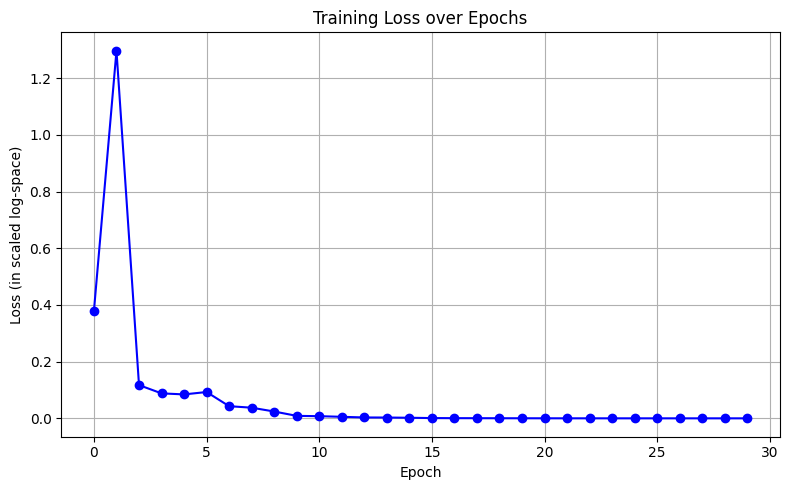

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step


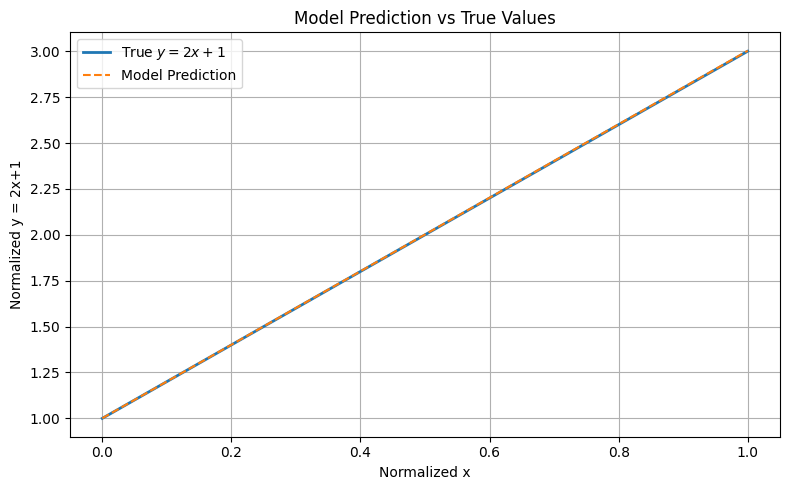

In [15]:

import tensorflow as tf
import numpy as np




class LogSpaceDense(tf.keras.layers.Layer):
    def __init__(self, units,activation=None, **kwargs):
        super(LogSpaceDense, self).__init__(**kwargs)
        self.units = units
        self.activation=activation

    def build(self, input_shape):
        input_dim = input_shape[-1]

        initial_w = tf.random.uniform(shape=(input_dim, self.units), minval=1, maxval=2, dtype=tf.int64)
        initial_b = tf.random.uniform(shape=(self.units,), minval=0.001, maxval=0.01, dtype=tf.float64)

        # Convert to LNS
        self.log_w = self.add_weight(shape=(input_dim, self.units),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_w.numpy()).nd),
                                    trainable=True, dtype=tf.float64)
        self.log_b = self.add_weight(shape=(self.units,),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_b.numpy()).nd),
                                    trainable=True, dtype=tf.float64)



    @tf.custom_gradient
    def call(self, log_inputs):     #forward pass
        #print("forward pass w",lns_to_float(self.log_w))
        #print("forward pass b",lns_to_float(self.log_b))
        log_output = lns_add_int64(lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w), self.log_b)
        #log_output=lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w)
        #print('log input',lns_to_float(log_inputs))
        #print("log output",lns_to_float(log_output))
        if self.activation:
            log_output = self.activation(log_output)

        def grad(dy, variables=None):
            #print("grad",dy)
            #print("variables",variables)
            #dy2=tf.convert_to_tensor(xl.xlnsnp(dy).nd,dtype=tf.float64)
            a=lns_matmul_int64(tf.transpose(log_inputs), dy)
            #print("dy in layer", lns_to_float(dy))
            #print("a after lns in layer",lns_to_float(a)) #a sign for specific numbers

            #t=tf.matmul(lns_to_float(tf.transpose(log_inputs)),lns_to_float(dy))
            #print(tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64))
            #print("TF matmul",t)
            grad_log_w =a #tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64) # tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64) #lns_sub_int64(a, self.log_w)
            #grad_log_b  = tf.reduce_sum(dy, axis=0)
            grad_log_b = dy[0]
            for i in range(1, tf.shape(dy)[0]):
                grad_log_b = lns_add_int64(grad_log_b, dy[i])
            #print("dy",tf.shape(dy))
            #print("w",tf.shape(self.log_w))
            grad_inputs = lns_matmul_int64(dy, tf.transpose(self.log_w)) #Transpose needed for backprop
            #print("bias",grad_log_b)
            return grad_inputs, [grad_log_w, grad_log_b]

        return tf.convert_to_tensor(log_output,dtype=tf.float64), grad
    def compute_output_shape(self, input_shape):
        """Define the output shape explicitly"""
        return (input_shape[0], self.units)



@tf.custom_gradient
def log_mse_loss(y_true_log, y_pred_log):

    # log_e = log(y_true - y_pred)
    diff = lns_sub_int64(y_true_log, y_pred_log)
    diff_sq = lns_mul_int64(diff, diff)
    #print("true, pred",lns_to_float(y_true_log),lns_to_float(y_pred_log))
    #print("diff_sq",lns_to_float(diff_sq)) #diff is correct with sign
    # log_sum_se = sum of squared errors in log-space
    log_sum_se = diff_sq[0]
    for i in range(1, tf.shape(diff_sq)[0]):
        log_sum_se = lns_add_int64(log_sum_se, diff_sq[i])
    #print(tf.size(y_true_log))
    #log_n = tf.math.log(tf.cast(tf.size(y_true_log), tf.float64))*2**24/tf.math.log(tf.cast(2.0,tf.float64))  # log(batch size)
    #print(np.array(tf.size(y_true_log)))
    log_n=xl.xlnsnp(np.array([np.array(tf.size(y_true_log))])).nd[0]
    log_mse = log_sum_se - log_n  # log(MSE)
    #print("log_mse",lns_to_float(log_mse),lns_to_float(log_sum_se),lns_to_float(log_n))
    def grad(dlog_mse,variables=None):
       # print("dlog_mse",dlog_mse) it is mostly 1 but not in log space
        dy = lns_mul_int64(tf.constant((2**24), dtype=tf.float64),  # ln(2) base 2 is just scaled 1
                           lns_sub_int64(y_pred_log, y_true_log))  -log_n
        #print("lns_sub",lns_to_float(lns_sub_int64(y_pred_log, y_true_log)))
        #print("logn",log_n)

        dy=tf.where(tf.math.is_inf(lns_to_float(dy)), tf.constant(xl.xlnsnp(np.array([0])).nd[0], dtype=tf.float64), dy)

        #dy = lns_mul_int64(dlog_mse, dy)
        #print("dy2", 2*(lns_to_float(y_pred_log)-lns_to_float(y_true_log))/5)

        dy_true = lns_mul_int64(0, lns_sub_int64(y_true_log, y_pred_log))
        #print("dy",lns_to_float(dy))
        return dy_true, dy

    return log_mse, grad




class LogSpaceSGD(tf.keras.optimizers.Optimizer):
    def __init__(self, learning_rate=1, name="LogSpaceSGD", **kwargs):

        super().__init__(learning_rate, **kwargs)
        self.learning_rate = tf.constant((np.log2(learning_rate) * (2**24)),dtype=tf.float64)
        self.learning_rate=xl.xlnsnp(np.array([learning_rate])).nd[0]
    def apply_gradients(self, grads_and_vars, name=None, experimental_aggregate_gradients=True):
        for grad, var in grads_and_vars:

            if grad is not None:
                #print("grad in optimizer",lns_to_float(grad)) #same as the grad of weight and bias given by layer
                #print(lns_matmul_int64(self.learning_rate, grad))
                #print("learning rate",lns_to_float(self.learning_rate))
                l=lns_mul_int64(self.learning_rate, grad)
                #print("variable in optimizer",lns_to_float(var))

                a=lns_sub_int64(var, l)        #addition happening

                a=tf.convert_to_tensor(xl.xlnsnp(np.array(lns_to_float(var)-lns_to_float(l))).nd,dtype=tf.float64)

                var.assign(a)
                #print("variable update is",lns_to_float(l))
                #print("var after sub",lns_to_float(var))
        return tf.no_op()


#model = tf.keras.Sequential([LogSpaceDense(units=2, input_shape=(1,)), LogSpaceDense(units=1)]) #some issue with signs, values keep increasing
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    LogSpaceDense(units=2,dtype=tf.float64,activation=log_relu),
    LogSpaceDense(units=2,dtype=tf.float64,activation=log_relu), #dtype necessary
    LogSpaceDense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer=LogSpaceSGD(learning_rate=0.1), loss=log_mse_loss)
model.summary()
"""for layer in model.layers:
    print(f"Layer {layer.name} input dtype:", layer.input_dtype)
    print(f"Layer {layer.name} output dtype:", layer.dtype)"""



x_train_fp=np.linspace(0.1, 1.0, 50).reshape(-1, 1)

def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

# Normalize x_train and y_train
x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
#y_train_fp_normalized = min_max_scaling(y_train_fp)
y_train_fp_normalized=x_train_fp_normalized*2 +1

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)

#print(x_train_fp_normalized,y_train_fp_normalized)

history=model.fit(x_train_log, y_train_log, epochs=30, verbose=2)
loss_values = history.history['loss']
loss_values = [lns_to_float(l) for l in loss_values]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

x_test_fp = np.linspace(0.1, 1.0, 100).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)

# Convert to log-space
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_log = model.predict(x_test_log)
prediction_fp = lns_to_float(prediction_log)

# True y = x^2 (from normalized x)
true_y = x_test_fp_normalized * 2 +1

plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = 2x+1$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_fp, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = 2x+1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
lns_to_float(-2.9812e+08)

<tf.Tensor: shape=(), dtype=float64, numpy=4.476067736646924e-06>

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (104.00 B)

 Trainable params: 13 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 - 0s - 187ms/step - loss: 4.6676
Epoch 2/100
2/2 - 1s - 338ms/step - loss: 3.9791
Epoch 3/100
2/2 - 1s - 308ms/step - loss: 3.6901
Epoch 4/100
2/2 - 0s - 215ms/step - loss: 3.4301
Epoch 5/100
2/2 - 0s - 95ms/step - loss: 3.1888
Epoch 6/100
2/2 - 0s - 163ms/step - loss: 2.9664
Epoch 7/100
2/2 - 0s - 160ms/step - loss: 2.7641
Epoch 8/100
2/2 - 0s - 125ms/step - loss: 2.5786
Epoch 9/100
2/2 - 0s - 181ms/step - loss: 2.4062
Epoch 10/100
2/2 - 0s - 112ms/step - loss: 2.2482
Epoch 11/100
2/2 - 0s - 167ms/step - loss: 2.1013
Epoch 12/100
2/2 - 1s - 265ms/step - loss: 1.9632
Epoch 13/100
2/2 - 0s - 181ms/step - loss: 1.8361
Epoch 14/100
2/2 - 1s - 253ms/step - loss: 1.7198
Epoch 15/100
2/2 - 0s - 232ms/step - loss: 1.6117
Epoch 16/100
2/2 - 0s - 146ms/step - loss: 1.5110
Epoch 17/100
2/2 - 0s - 100ms/step - loss: 1.4181
Epoch 18/100
2/2 - 0s - 142ms/step - loss: 1.3343
Epoch 19/100
2/2 - 0s - 133ms/step - loss: 1.2585
Epoch 20/100
2/2 - 0s - 166ms/step - loss: 1.1881
Epoch 21/1

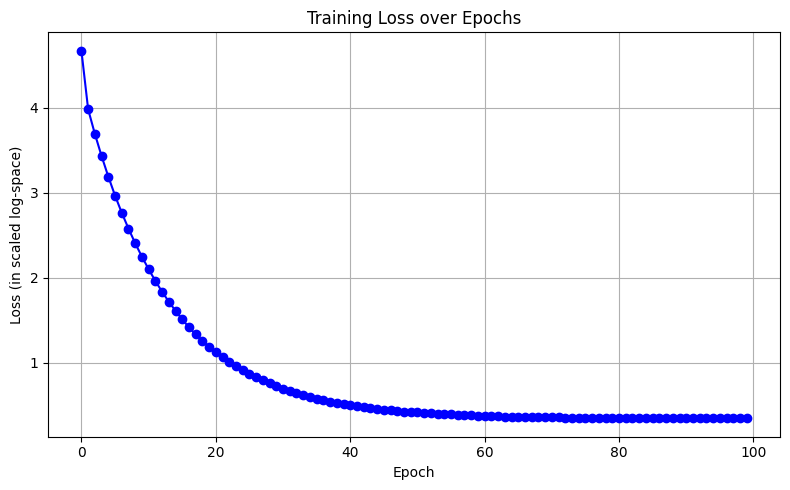

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


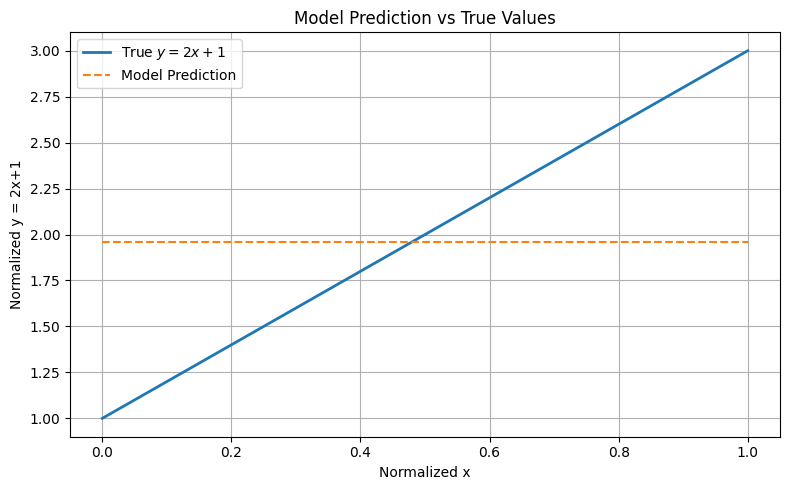

In [17]:
from tensorflow.keras.losses import MeanSquaredError  # Import the MSE loss function



mse_loss = MeanSquaredError()
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    tf.keras.layers.Dense(units=2,dtype=tf.float64,activation='relu'),
    tf.keras.layers.Dense(units=2,dtype=tf.float64,activation='relu'), #dtype necessary
    tf.keras.layers.Dense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer='sgd', loss=mse_loss)
model.summary()
"""for layer in model.layers:
    print(f"Layer {layer.name} input dtype:", layer.input_dtype)
    print(f"Layer {layer.name} output dtype:", layer.dtype)"""


x_train_fp=np.linspace(0.1, 1.0, 50).reshape(-1, 1)

def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

# Normalize x_train and y_train
x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
#y_train_fp_normalized = min_max_scaling(y_train_fp)
y_train_fp_normalized=x_train_fp_normalized*2+1

#x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

#y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)

#print(x_train_fp_normalized,y_train_fp_normalized)

history=model.fit(x_train_fp_normalized, y_train_fp_normalized, epochs=100, verbose=2)
loss_values = history.history['loss']
#loss_values = [lns_to_float(l) for l in loss_values]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

x_test_fp = np.linspace(0.1, 1.0, 100).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)

# Convert to log-space
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_fp = model.predict(x_test_fp_normalized)
#prediction_fp = lns_to_float(prediction_log)

# True y = x^2 (from normalized x)
true_y = x_test_fp_normalized * 2+1


plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = 2x+1$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_fp, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = 2x+1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Experiment 2: Non-Linear Function (y = x²)

In this experiment, the square function is used for curve-fitting. The experimentations are done with a shallow model (2 layers with 2-1 neurons) and a deeper model (3 layers 2-2-1 neurons). **Log-space Model** showed (45 times) better convergence  than corresponding keras dense model for the 2 layer model and (90 times) better convergence for the 3 layer model for the same number of epochs (30) in both the cases.

- **Log-Space Model Loss**: 0.004521023151209808, 0.0017727732960469784
- **Keras Dense Model Loss**: 0.2107, 0.1714


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_26              │ (None, 2)              │             4 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_27              │ (None, 1)              │             3 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (56.00 B)

 Trainable params: 7 (56.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
grad in optimizer tf.Tensor([[0.90583328]], shape=(1, 1), dtype=float64)
variable in optimizer tf.Tensor([[1. 1.]], shape=(1, 2), dtype=float64)
var after sub tf.Tensor([[0.90941669 0.90941669]], shape=(1, 2), dtype=float64)
grad in optimizer tf.Tensor([1.41603102], shape=(1,), dtype=float64)
variable in optimizer tf.Tensor([0.00751239 0.00951234], shape=(2,), dtype=float64)
var after sub tf.Tensor([-0.13409071 -0.13209076], shape=(2,), dtype=float64)
grad in optimizer tf.Tensor(
[[0.91647099]
 [0.91930303]], shape=(2, 1), dtype=float64)
variable in optimizer tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float64)
var after sub tf.Tensor(
[[0.90835289]
 [0.90806967]], shape=(2, 1), dtype=float64)
grad in optimizer tf.Tensor([1.41603102], shape=(1,), dtype=float64)
variable in optimizer tf.Tensor([0.00134376], shape=(1,), dtype=float64)
var after sub tf.Tensor([-0.14025933], shape=(1,), dtype=float64)
grad in optimizer tf.Tensor([[0.17340715]], shape=(1, 1), dtype=float64)
vari

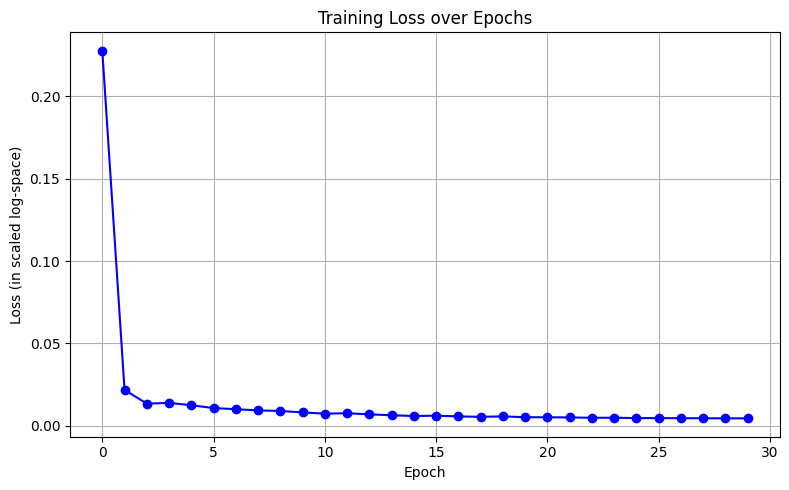

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step


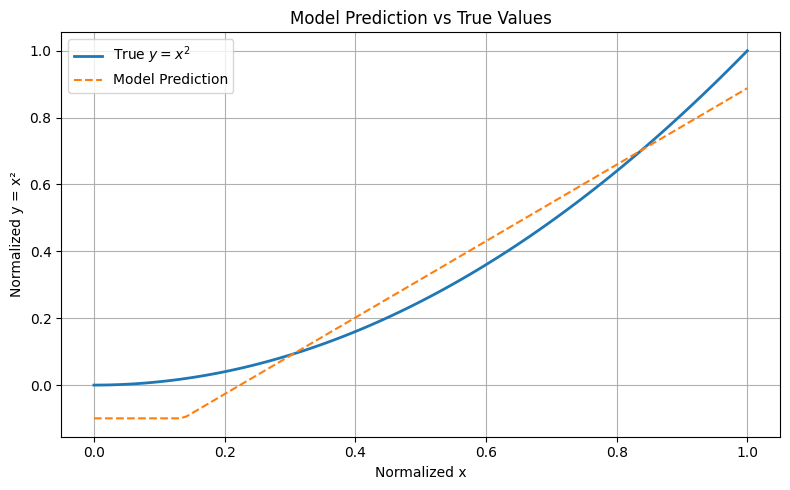

In [ ]:

import tensorflow as tf
import numpy as np




class LogSpaceDense(tf.keras.layers.Layer):
    def __init__(self, units,activation=None, **kwargs):
        super(LogSpaceDense, self).__init__(**kwargs)
        self.units = units
        self.activation=activation

    def build(self, input_shape):
        input_dim = input_shape[-1]

        initial_w = tf.random.uniform(shape=(input_dim, self.units), minval=1, maxval=2, dtype=tf.int64)
        initial_b = tf.random.uniform(shape=(self.units,), minval=0.001, maxval=0.01, dtype=tf.float64)

        # Convert to LNS
        self.log_w = self.add_weight(shape=(input_dim, self.units),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_w.numpy()).nd),
                                    trainable=True, dtype=tf.float64)
        self.log_b = self.add_weight(shape=(self.units,),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_b.numpy()).nd),
                                    trainable=True, dtype=tf.float64)



    @tf.custom_gradient
    def call(self, log_inputs):     #forward pass
        #print("forward pass w",lns_to_float(self.log_w)) #variable after updation from optimizer, check this sign
        #print("forward pass b",lns_to_float(self.log_b))
        log_output = lns_add_int64(lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w), self.log_b)
        #log_output=lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w)
        #print('log input',lns_to_float(log_inputs))
        #print("log output",lns_to_float(log_output))
        if self.activation:
            log_output = self.activation(log_output)

        def grad(dy, variables=None):
            #print("grad",dy)
            #print("variables",variables)
            dy2=tf.convert_to_tensor(xl.xlnsnp(dy).nd,dtype=tf.float64)
            a=lns_matmul_int64(tf.transpose(log_inputs), dy)
            #print("dy in layer", lns_to_float(dy))
            #print("log_inputs in layer",lns_to_float(log_inputs))
            #print("a after lns in layer",lns_to_float(a)) #a sign for specific numbers

            t=tf.matmul(lns_to_float(tf.transpose(log_inputs)),lns_to_float(dy))
            #print(tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64))
            #print("TF matmul",t)
            grad_log_w =a #tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64) # tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64) #lns_sub_int64(a, self.log_w)
            #grad_log_b  = tf.reduce_sum(dy, axis=0)
            grad_log_b = dy[0]
            for i in range(1, tf.shape(dy)[0]):
                grad_log_b = lns_add_int64(grad_log_b, dy[i])
            grad_inputs = lns_matmul_int64(dy, self.log_w)
            #print("bias",grad_log_b)
            return grad_inputs, [grad_log_w, grad_log_b]

        return tf.convert_to_tensor(log_output,dtype=tf.float64), grad
    def compute_output_shape(self, input_shape):
        """Define the output shape explicitly"""
        return (input_shape[0], self.units)



@tf.custom_gradient
def log_mse_loss(y_true_log, y_pred_log):
    # log_e = log(y_true - y_pred)
    diff = lns_sub_int64(y_true_log, y_pred_log)
    diff_sq = lns_mul_int64(diff, diff)
    #print("true, pred",lns_to_float(y_true_log),lns_to_float(y_pred_log))
    #print("diff_sq",lns_to_float(diff_sq)) #diff is correct with sign
    # log_sum_se = sum of squared errors in log-space
    log_sum_se = diff_sq[0]
    for i in range(1, tf.shape(diff_sq)[0]):
        log_sum_se = lns_add_int64(log_sum_se, diff_sq[i])
    #print(tf.size(y_true_log))
    #log_n = tf.math.log(tf.cast(tf.size(y_true_log), tf.float64))*2**24/tf.math.log(tf.cast(2.0,tf.float64))  # log(batch size)
    #print(np.array(tf.size(y_true_log)))
    log_n=xl.xlnsnp(np.array([np.array(tf.size(y_true_log))])).nd[0]
    log_mse = log_sum_se - log_n  # log(MSE)
    #print("log_mse",lns_to_float(log_mse),lns_to_float(log_sum_se),lns_to_float(log_n))
    def grad(dlog_mse,variables=None):
       # print("dlog_mse",dlog_mse) it is mostly 1 but not in log space
        dy = lns_mul_int64(tf.constant((2**24), dtype=tf.float64),  # ln(2) base 2 is just scaled 1
                           lns_sub_int64(y_pred_log, y_true_log))  -log_n
        #print("lns_sub",lns_to_float(lns_sub_int64(y_pred_log, y_true_log)))
        #print("logn",log_n)

        dy=tf.where(tf.math.is_inf(lns_to_float(dy)), tf.constant(xl.xlnsnp(np.array([0])).nd[0], dtype=tf.float64), dy)

        #dy = lns_mul_int64(dlog_mse, dy)
        #print("dy2", 2*(lns_to_float(y_pred_log)-lns_to_float(y_true_log))/5)

        dy_true = lns_mul_int64(0, lns_sub_int64(y_true_log, y_pred_log))
        #print("dy",lns_to_float(dy))
        return dy_true, dy

    return log_mse, grad




class LogSpaceSGD(tf.keras.optimizers.Optimizer):
    def __init__(self, learning_rate=1, name="LogSpaceSGD", **kwargs):

        super().__init__(learning_rate, **kwargs)
        self.learning_rate = tf.constant((np.log2(learning_rate) * (2**24)),dtype=tf.float64)
        self.learning_rate=xl.xlnsnp(np.array([learning_rate])).nd[0]
    def apply_gradients(self, grads_and_vars, name=None, experimental_aggregate_gradients=True):
        for grad, var in grads_and_vars:

            if grad is not None:
                print("grad in optimizer",lns_to_float(grad))
                #print(lns_matmul_int64(self.learning_rate, grad))
                #print("learning rate",lns_to_float(self.learning_rate))
                l=lns_mul_int64(self.learning_rate, grad)
                print("variable in optimizer",lns_to_float(var))

                a=lns_sub_int64(var, l)

                a=tf.convert_to_tensor(xl.xlnsnp(np.array(lns_to_float(var)-lns_to_float(l))).nd,dtype=tf.float64)

                var.assign(a)
                #print("variable update is",lns_to_float(l))
                print("var after sub",lns_to_float(var))
        return tf.no_op()


#model = tf.keras.Sequential([LogSpaceDense(units=2, input_shape=(1,)), LogSpaceDense(units=1)])
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    LogSpaceDense(units=2,dtype=tf.float64,activation=log_relu), #dtype necessary
    LogSpaceDense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer=LogSpaceSGD(learning_rate=0.1), loss=log_mse_loss)
model.summary()
"""for layer in model.layers:
    print(f"Layer {layer.name} input dtype:", layer.input_dtype)
    print(f"Layer {layer.name} output dtype:", layer.dtype)"""



x_train_fp=np.linspace(0.1, 1.0, 50).reshape(-1, 1)

def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

# Normalize x_train and y_train
x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
#y_train_fp_normalized = min_max_scaling(y_train_fp)
y_train_fp_normalized=x_train_fp_normalized**2

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)

#print(x_train_fp_normalized,y_train_fp_normalized)

history=model.fit(x_train_log, y_train_log, epochs=30, verbose=2)
loss_values = history.history['loss']
loss_values = [lns_to_float(l) for l in loss_values]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

x_test_fp = np.linspace(0.1, 1.0, 100).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)

# Convert to log-space
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_log = model.predict(x_test_log)
prediction_fp = lns_to_float(prediction_log)

# True y = x^2 (from normalized x)
true_y = x_test_fp_normalized ** 2

# Plot predicted vs actual
plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = x^2$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_fp, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = x²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (56.00 B)

 Trainable params: 7 (56.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


2/2 - 0s - 96ms/step - loss: 0.2970
Epoch 2/30
2/2 - 0s - 135ms/step - loss: 0.2933
Epoch 3/30
2/2 - 0s - 152ms/step - loss: 0.2899
Epoch 4/30
2/2 - 0s - 122ms/step - loss: 0.2865
Epoch 5/30
2/2 - 0s - 78ms/step - loss: 0.2829
Epoch 6/30
2/2 - 0s - 64ms/step - loss: 0.2795
Epoch 7/30
2/2 - 0s - 69ms/step - loss: 0.2760
Epoch 8/30
2/2 - 0s - 79ms/step - loss: 0.2725
Epoch 9/30
2/2 - 0s - 55ms/step - loss: 0.2693
Epoch 10/30
2/2 - 0s - 49ms/step - loss: 0.2663
Epoch 11/30
2/2 - 0s - 70ms/step - loss: 0.2629
Epoch 12/30
2/2 - 0s - 70ms/step - loss: 0.2597
Epoch 13/30
2/2 - 0s - 71ms/step - loss: 0.2566
Epoch 14/30
2/2 - 0s - 69ms/step - loss: 0.2536
Epoch 15/30
2/2 - 0s - 70ms/step - loss: 0.2506
Epoch 16/30
2/2 - 0s - 100ms/step - loss: 0.2475
Epoch 17/30
2/2 - 0s - 236ms/step - loss: 0.2448
Epoch 18/30
2/2 - 0s - 154ms/step - loss: 0.2418
Epoch 19/30
2/2 - 0s - 68ms/step - loss: 0.2390
Epoch 20/30
2/2 - 0s - 74ms/step - loss: 0.2362
Epoch 21/30
2/2 - 0s - 63ms/step - loss: 0.2336
Epoch 

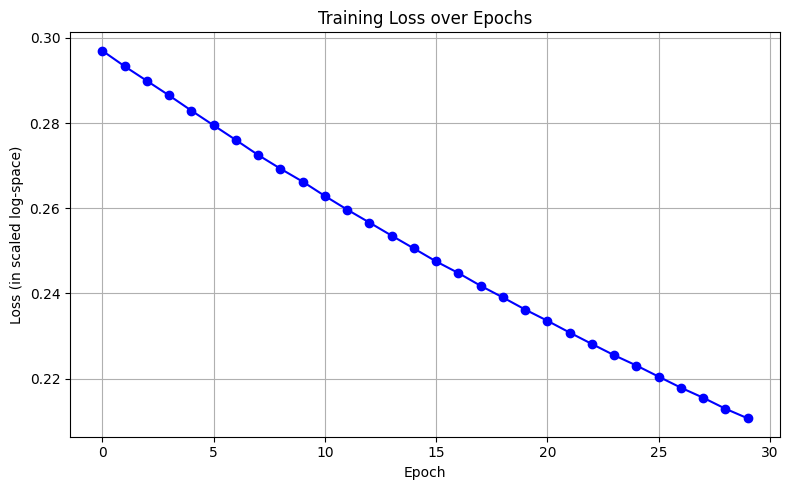

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


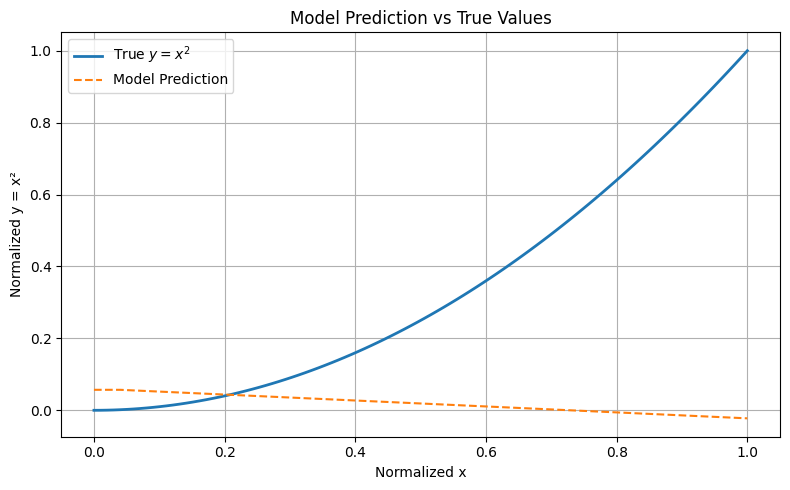

In [ ]:
from tensorflow.keras.losses import MeanSquaredError  # Import the MSE loss function



mse_loss = MeanSquaredError()
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    tf.keras.layers.Dense(units=2,dtype=tf.float64,activation='relu'), #dtype necessary
    tf.keras.layers.Dense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer='adam', loss=mse_loss)
model.summary()
"""for layer in model.layers:
    print(f"Layer {layer.name} input dtype:", layer.input_dtype)
    print(f"Layer {layer.name} output dtype:", layer.dtype)"""


x_train_fp=np.linspace(0.1, 1.0, 50).reshape(-1, 1)
y_train_fp = np.array([[2.0], [4.0], [6.0], [8.0], [10.0],[200.0]], dtype=np.float64)
def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

# Normalize x_train and y_train
x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
#y_train_fp_normalized = min_max_scaling(y_train_fp)
y_train_fp_normalized=x_train_fp_normalized**2

#x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

#y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)

#print(x_train_fp_normalized,y_train_fp_normalized)

history=model.fit(x_train_fp_normalized, y_train_fp_normalized, epochs=30, verbose=2)
loss_values = history.history['loss']
#loss_values = [lns_to_float(l) for l in loss_values]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

x_test_fp = np.linspace(0.1, 1.0, 100).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)

# Convert to log-space
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_fp = model.predict(x_test_fp_normalized)
#prediction_fp = lns_to_float(prediction_log)

# True y = x^2 (from normalized x)
true_y = x_test_fp_normalized ** 2


plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = x^2$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_fp, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = x²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_87              │ (None, 2)              │             4 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_88              │ (None, 2)              │             6 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_89              │ (None, 1)              │             3 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (104.00 B)

 Trainable params: 13 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2/2 - 5s - 2s/step - loss: 14068681.0000
Epoch 2/30
2/2 - 4s - 2s/step - loss: -3.1413e+07
Epoch 3/30
2/2 - 6s - 3s/step - loss: -8.5360e+07
Epoch 4/30
2/2 - 4s - 2s/step - loss: -1.4050e+08
Epoch 5/30
2/2 - 6s - 3s/step - loss: -1.4972e+08
Epoch 6/30
2/2 - 5s - 2s/step - loss: -1.5114e+08
Epoch 7/30
2/2 - 4s - 2s/step - loss: -1.5177e+08
Epoch 8/30
2/2 - 5s - 3s/step - loss: -1.5089e+08
Epoch 9/30
2/2 - 4s - 2s/step - loss: -1.5084e+08
Epoch 10/30
2/2 - 5s - 3s/step - loss: -1.5142e+08
Epoch 11/30
2/2 - 5s - 3s/step - loss: -1.5147e+08
Epoch 12/30
2/2 - 10s - 5s/step - loss: -1.5078e+08
Epoch 13/30
2/2 - 9s - 5s/step - loss: -1.5126e+08
Epoch 14/30
2/2 - 5s - 3s/step - loss: -1.5148e+08
Epoch 15/30
2/2 - 10s - 5s/step - loss: -1.5137e+08
Epoch 16/30
2/2 - 5s - 2s/step - loss: -1.5164e+08
Epoch 17/30
2/2 - 4s - 2s/step - loss: -1.5204e+08
Epoch 18/30
2/2 - 6s - 3s/step - loss: -1.5251e+08
Epoch 19/30
2/2 - 4s - 2s/step - loss: -1.5222e+08
Epoch 20/30
2/2 - 6s - 3s/step - los

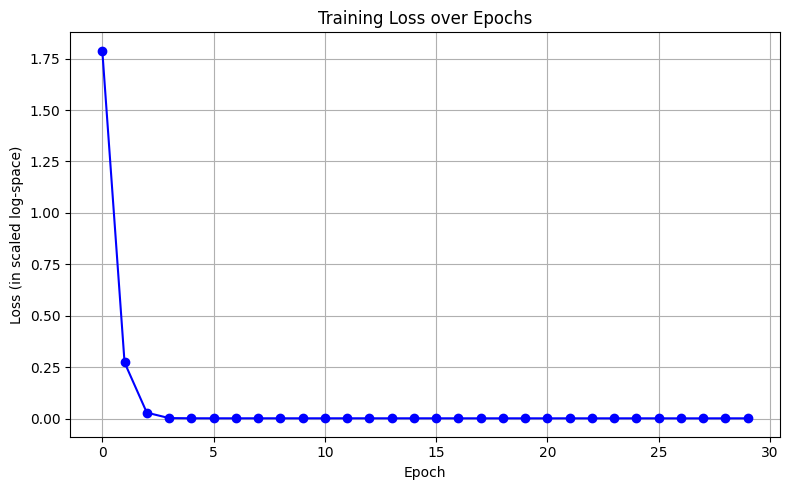

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 737ms/step


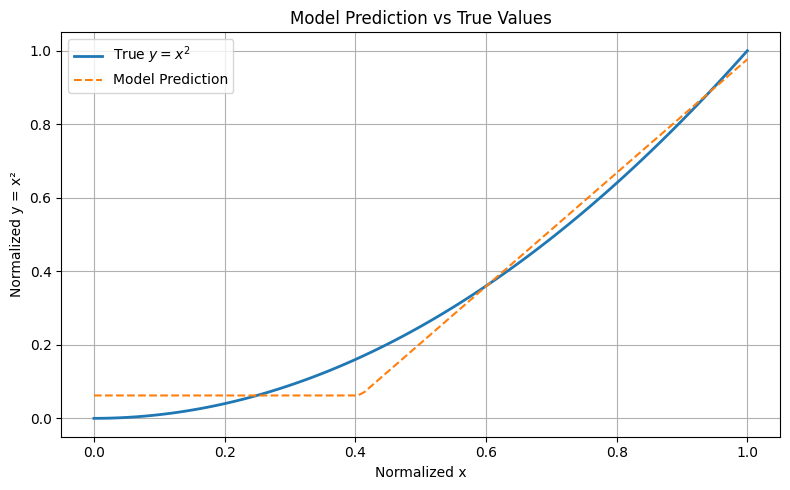

In [ ]:
#Deeper model comparison
import tensorflow as tf
import numpy as np




class LogSpaceDense(tf.keras.layers.Layer):
    def __init__(self, units,activation=None, **kwargs):
        super(LogSpaceDense, self).__init__(**kwargs)
        self.units = units
        self.activation=activation

    def build(self, input_shape):
        input_dim = input_shape[-1]

        initial_w = tf.random.uniform(shape=(input_dim, self.units), minval=1, maxval=2, dtype=tf.int64)
        initial_b = tf.random.uniform(shape=(self.units,), minval=0.001, maxval=0.01, dtype=tf.float64)

        # Convert to LNS
        self.log_w = self.add_weight(shape=(input_dim, self.units),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_w.numpy()).nd),
                                    trainable=True, dtype=tf.float64)
        self.log_b = self.add_weight(shape=(self.units,),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_b.numpy()).nd),
                                    trainable=True, dtype=tf.float64)



    @tf.custom_gradient
    def call(self, log_inputs):     #forward pass
        #print("forward pass w",lns_to_float(self.log_w))
        #print("forward pass b",lns_to_float(self.log_b))
        log_output = lns_add_int64(lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w), self.log_b)
        #log_output=lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w)
        #print('log input',lns_to_float(log_inputs))
        #print("log output",lns_to_float(log_output))
        if self.activation:
            log_output = self.activation(log_output)

        def grad(dy, variables=None):
            #print("grad",dy)
            #print("variables",variables)
            dy2=tf.convert_to_tensor(xl.xlnsnp(dy).nd,dtype=tf.float64)
            a=lns_matmul_int64(tf.transpose(log_inputs), dy)
            #print("dy in layer", lns_to_float(dy))
            #print("a after lns in layer",lns_to_float(a)) #a sign for specific numbers

            t=tf.matmul(lns_to_float(tf.transpose(log_inputs)),lns_to_float(dy))
            #print(tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64))
            #print("TF matmul",t)
            grad_log_w =a #tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64) # tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64) #lns_sub_int64(a, self.log_w)
            #grad_log_b  = tf.reduce_sum(dy, axis=0)
            grad_log_b = dy[0]
            for i in range(1, tf.shape(dy)[0]):
                grad_log_b = lns_add_int64(grad_log_b, dy[i])
            #print("dy",tf.shape(dy))
            #print("w",tf.shape(self.log_w))
            grad_inputs = lns_matmul_int64(dy, tf.transpose(self.log_w)) #Transpose needed for backprop
            #print("bias",grad_log_b)
            return grad_inputs, [grad_log_w, grad_log_b]

        return tf.convert_to_tensor(log_output,dtype=tf.float64), grad
    def compute_output_shape(self, input_shape):
        """Define the output shape explicitly"""
        return (input_shape[0], self.units)



@tf.custom_gradient
def log_mse_loss(y_true_log, y_pred_log):

    # log_e = log(y_true - y_pred)
    diff = lns_sub_int64(y_true_log, y_pred_log)
    diff_sq = lns_mul_int64(diff, diff)
    #print("true, pred",lns_to_float(y_true_log),lns_to_float(y_pred_log))
    #print("diff_sq",lns_to_float(diff_sq)) #diff is correct with sign
    # log_sum_se = sum of squared errors in log-space
    log_sum_se = diff_sq[0]
    for i in range(1, tf.shape(diff_sq)[0]):
        log_sum_se = lns_add_int64(log_sum_se, diff_sq[i])
    #print(tf.size(y_true_log))
    #log_n = tf.math.log(tf.cast(tf.size(y_true_log), tf.float64))*2**24/tf.math.log(tf.cast(2.0,tf.float64))  # log(batch size)
    #print(np.array(tf.size(y_true_log)))
    log_n=xl.xlnsnp(np.array([np.array(tf.size(y_true_log))])).nd[0]
    log_mse = log_sum_se - log_n  # log(MSE)
    #print("log_mse",lns_to_float(log_mse),lns_to_float(log_sum_se),lns_to_float(log_n))
    def grad(dlog_mse,variables=None):
       # print("dlog_mse",dlog_mse) it is mostly 1 but not in log space
        dy = lns_mul_int64(tf.constant((2**24), dtype=tf.float64),  # ln(2) base 2 is just scaled 1
                           lns_sub_int64(y_pred_log, y_true_log))  -log_n
        #print("lns_sub",lns_to_float(lns_sub_int64(y_pred_log, y_true_log)))
        #print("logn",log_n)

        dy=tf.where(tf.math.is_inf(lns_to_float(dy)), tf.constant(xl.xlnsnp(np.array([0])).nd[0], dtype=tf.float64), dy)

        #dy = lns_mul_int64(dlog_mse, dy)
        #print("dy2", 2*(lns_to_float(y_pred_log)-lns_to_float(y_true_log))/5)

        dy_true = lns_mul_int64(0, lns_sub_int64(y_true_log, y_pred_log))
        #print("dy",lns_to_float(dy))
        return dy_true, dy

    return log_mse, grad




class LogSpaceSGD(tf.keras.optimizers.Optimizer):
    def __init__(self, learning_rate=1, name="LogSpaceSGD", **kwargs):

        super().__init__(learning_rate, **kwargs)
        self.learning_rate = tf.constant((np.log2(learning_rate) * (2**24)),dtype=tf.float64)
        self.learning_rate=xl.xlnsnp(np.array([learning_rate])).nd[0]
    def apply_gradients(self, grads_and_vars, name=None, experimental_aggregate_gradients=True):
        for grad, var in grads_and_vars:

            if grad is not None:
                #print("grad in optimizer",lns_to_float(grad)) #same as the grad of weight and bias given by layer
                #print(lns_matmul_int64(self.learning_rate, grad))
                #print("learning rate",lns_to_float(self.learning_rate))
                l=lns_mul_int64(self.learning_rate, grad)
                #print("variable in optimizer",lns_to_float(var))

                a=lns_sub_int64(var, l)        #addition happening

                a=tf.convert_to_tensor(xl.xlnsnp(np.array(lns_to_float(var)-lns_to_float(l))).nd,dtype=tf.float64)

                var.assign(a)
                #print("variable update is",lns_to_float(l))
                #print("var after sub",lns_to_float(var))
        return tf.no_op()


#model = tf.keras.Sequential([LogSpaceDense(units=2, input_shape=(1,)), LogSpaceDense(units=1)]) #some issue with signs, values keep increasing
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    LogSpaceDense(units=2,dtype=tf.float64,activation=log_relu),
    LogSpaceDense(units=2,dtype=tf.float64,activation=log_relu), #dtype necessary
    LogSpaceDense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer=LogSpaceSGD(learning_rate=0.1), loss=log_mse_loss)
model.summary()
"""for layer in model.layers:
    print(f"Layer {layer.name} input dtype:", layer.input_dtype)
    print(f"Layer {layer.name} output dtype:", layer.dtype)"""



x_train_fp=np.linspace(0.1, 1.0, 50).reshape(-1, 1)

def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

# Normalize x_train and y_train
x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
#y_train_fp_normalized = min_max_scaling(y_train_fp)
y_train_fp_normalized=x_train_fp_normalized**2

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)

#print(x_train_fp_normalized,y_train_fp_normalized)

history=model.fit(x_train_log, y_train_log, epochs=30, verbose=2)
loss_values = history.history['loss']
loss_values = [lns_to_float(l) for l in loss_values]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

x_test_fp = np.linspace(0.1, 1.0, 100).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)

# Convert to log-space
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_log = model.predict(x_test_log)
prediction_fp = lns_to_float(prediction_log)

# True y = x^2 (from normalized x)
true_y = x_test_fp_normalized ** 2

plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = x^2$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_fp, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = x²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (104.00 B)

 Trainable params: 13 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2/2 - 0s - 160ms/step - loss: 0.2058
Epoch 2/30
2/2 - 1s - 288ms/step - loss: 0.2046
Epoch 3/30
2/2 - 0s - 107ms/step - loss: 0.2032
Epoch 4/30
2/2 - 0s - 187ms/step - loss: 0.2019
Epoch 5/30
2/2 - 0s - 135ms/step - loss: 0.2007
Epoch 6/30
2/2 - 0s - 152ms/step - loss: 0.1993
Epoch 7/30
2/2 - 0s - 194ms/step - loss: 0.1981
Epoch 8/30
2/2 - 0s - 187ms/step - loss: 0.1968
Epoch 9/30
2/2 - 0s - 128ms/step - loss: 0.1955
Epoch 10/30
2/2 - 0s - 190ms/step - loss: 0.1943
Epoch 11/30
2/2 - 1s - 263ms/step - loss: 0.1930
Epoch 12/30
2/2 - 0s - 132ms/step - loss: 0.1918
Epoch 13/30
2/2 - 0s - 148ms/step - loss: 0.1905
Epoch 14/30
2/2 - 0s - 162ms/step - loss: 0.1893
Epoch 15/30
2/2 - 0s - 163ms/step - loss: 0.1881
Epoch 16/30
2/2 - 0s - 142ms/step - loss: 0.1869
Epoch 17/30
2/2 - 0s - 123ms/step - loss: 0.1857
Epoch 18/30
2/2 - 0s - 99ms/step - loss: 0.1845
Epoch 19/30
2/2 - 0s - 103ms/step - loss: 0.1834
Epoch 20/30
2/2 - 0s - 140ms/step - loss: 0.1822
Epoch 21/30
2/2 - 0s - 161ms/s

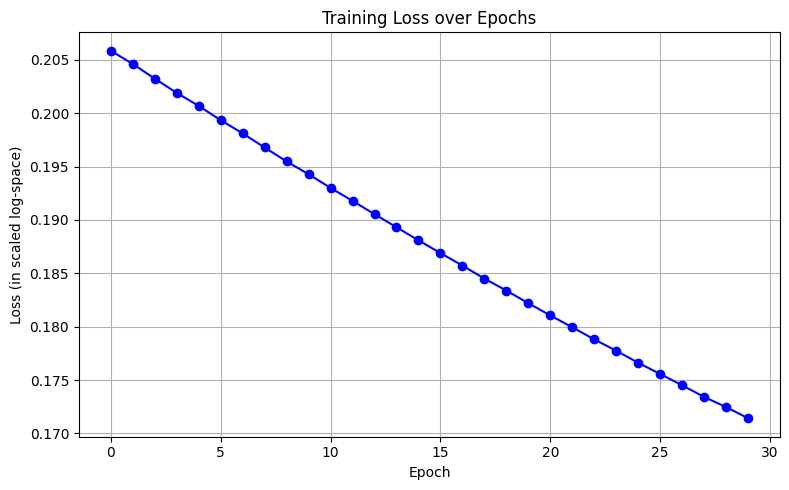

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


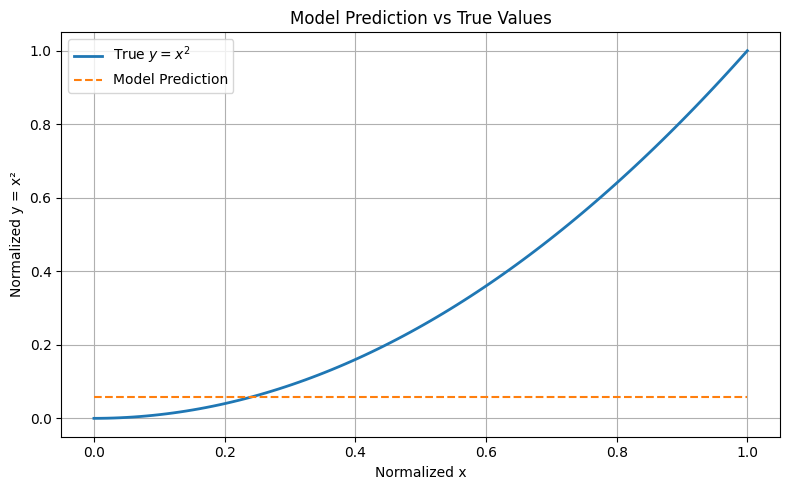

In [ ]:
from tensorflow.keras.losses import MeanSquaredError  # Import the MSE loss function



mse_loss = MeanSquaredError()
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    tf.keras.layers.Dense(units=2,dtype=tf.float64,activation='relu'),
    tf.keras.layers.Dense(units=2,dtype=tf.float64,activation='relu'), #dtype necessary
    tf.keras.layers.Dense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer='adam', loss=mse_loss)
model.summary()
"""for layer in model.layers:
    print(f"Layer {layer.name} input dtype:", layer.input_dtype)
    print(f"Layer {layer.name} output dtype:", layer.dtype)"""


x_train_fp=np.linspace(0.1, 1.0, 50).reshape(-1, 1)
y_train_fp = np.array([[2.0], [4.0], [6.0], [8.0], [10.0],[200.0]], dtype=np.float64)
def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

# Normalize x_train and y_train
x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
#y_train_fp_normalized = min_max_scaling(y_train_fp)
y_train_fp_normalized=x_train_fp_normalized**2

#x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

#y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)

#print(x_train_fp_normalized,y_train_fp_normalized)

history=model.fit(x_train_fp_normalized, y_train_fp_normalized, epochs=30, verbose=2)
loss_values = history.history['loss']
#loss_values = [lns_to_float(l) for l in loss_values]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

x_test_fp = np.linspace(0.1, 1.0, 100).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)

# Convert to log-space
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_fp = model.predict(x_test_fp_normalized)
#prediction_fp = lns_to_float(prediction_log)

# True y = x^2 (from normalized x)
true_y = x_test_fp_normalized ** 2

# Plot predicted vs actual
plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = x^2$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_fp, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = x²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Experiment 3: Periodic Function (y = sin(x))

In this final experiment, the periodic sine function is used with a 3 layer (8-8-1 neurons) model architecture. **Log-space Model** showed (7.5 times) better convergence  than corresponding keras dense model for the same number of epochs (50).

- **Log-Space Model Loss**: 0.00040626878367526937
- **Keras Dense Model Loss**: 0.0030


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_15              │ (None, 8)              │            16 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_16              │ (None, 8)              │            72 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_17              │ (None, 1)              │             9 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (776.00 B)

 Trainable params: 97 (776.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 - 12s - 12s/step - loss: -4.8670e+07 - learning_rate: -5.5733e+07
Epoch 2/50
1/1 - 19s - 19s/step - loss: -9.3068e+07 - learning_rate: -5.5733e+07
Epoch 3/50
1/1 - 34s - 34s/step - loss: -9.9550e+07 - learning_rate: -5.5733e+07
Epoch 4/50
1/1 - 16s - 16s/step - loss: -1.0288e+08 - learning_rate: -5.5733e+07
Epoch 5/50
1/1 - 10s - 10s/step - loss: -1.0615e+08 - learning_rate: -5.5733e+07
Epoch 6/50
1/1 - 10s - 10s/step - loss: -1.0934e+08 - learning_rate: -5.5733e+07
Epoch 7/50
1/1 - 10s - 10s/step - loss: -1.1244e+08 - learning_rate: -5.5733e+07
Epoch 8/50
1/1 - 10s - 10s/step - loss: -1.1547e+08 - learning_rate: -5.5733e+07
Epoch 9/50
1/1 - 10s - 10s/step - loss: -1.1843e+08 - learning_rate: -5.5733e+07
Epoch 10/50
1/1 - 11s - 11s/step - loss: -1.2132e+08 - learning_rate: -5.5733e+07
Epoch 11/50
1/1 - 10s - 10s/step - loss: -1.2420e+08 - learning_rate: -5.5733e+07
Epoch 12/50
1/1 - 10s - 10s/step - loss: -1.2710e+08 - learning_rate: -5.5733e+07
Epoch 13/50
1/1 - 10s - 1

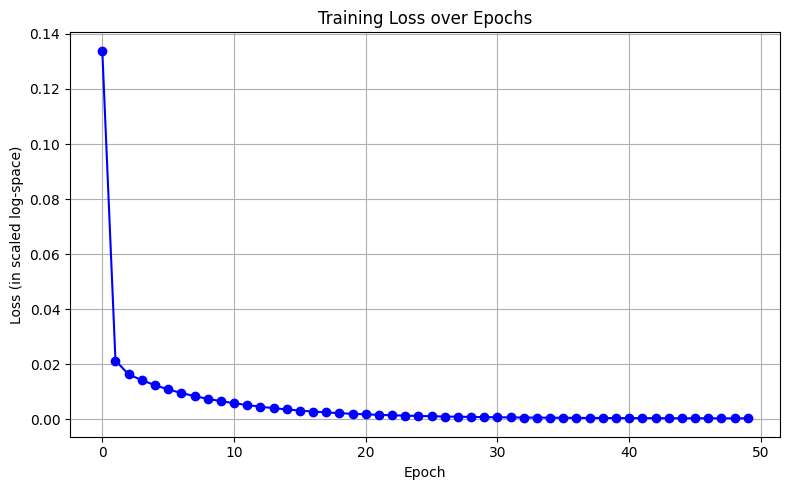

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
pred tf.Tensor(
[[0.11522067]
 [0.20073018]
 [0.28623968]
 [0.3717492 ]
 [0.45725871]
 [0.54276824]
 [0.62827777]
 [0.7137873 ]
 [0.79929681]
 [0.88480627]
 [0.97031581]
 [1.05582532]
 [1.14133484]
 [1.22684439]
 [1.31235392]
 [1.39786333]
 [1.48337285]
 [1.5688823 ]
 [1.65439195]
 [1.73990149]], shape=(20, 1), dtype=float64)


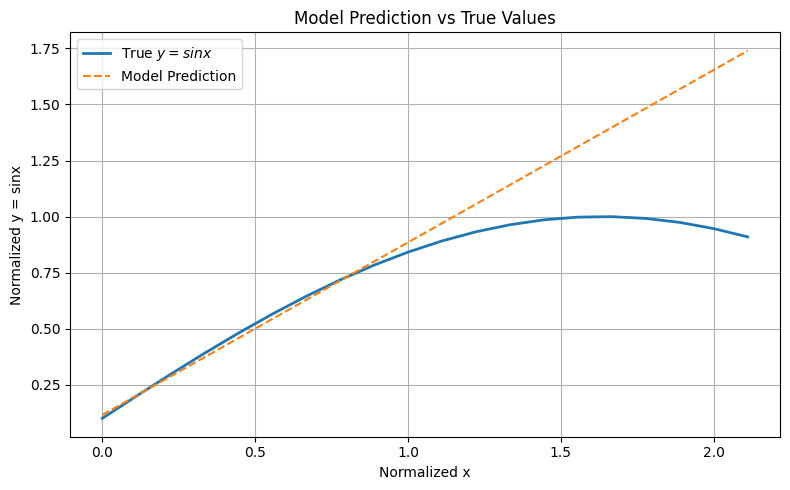

In [ ]:

import tensorflow as tf
import numpy as np
from tensorflow.keras.callbacks import ReduceLROnPlateau



class LogSpaceDense(tf.keras.layers.Layer):
    def __init__(self, units,activation=None, **kwargs):
        super(LogSpaceDense, self).__init__(**kwargs)
        self.units = units
        self.activation=activation

    def build(self, input_shape):
        input_dim = input_shape[-1]

        initial_w = tf.random.uniform(shape=(input_dim, self.units), minval=0.1, maxval=0.5, dtype=tf.float64)
        initial_b = tf.random.uniform(shape=(self.units,), minval=0.001, maxval=0.01, dtype=tf.float64)


        self.log_w = self.add_weight(shape=(input_dim, self.units),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_w.numpy()).nd),
                                    trainable=True, dtype=tf.float64)
        self.log_b = self.add_weight(shape=(self.units,),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_b.numpy()).nd),
                                    trainable=True, dtype=tf.float64)



    @tf.custom_gradient
    def call(self, log_inputs):
        log_output = lns_add_int64(lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w), self.log_b)

        if self.activation:
            log_output = self.activation(log_output)

        def grad(dy, variables=None):

            dy2=tf.convert_to_tensor(xl.xlnsnp(dy).nd,dtype=tf.float64)
            a=lns_matmul_int64(tf.transpose(log_inputs), dy)


            #t=tf.matmul(lns_to_float(tf.transpose(log_inputs)),lns_to_float(dy))
            #print(tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64))
            #print("TF matmul",t)
            grad_log_w =a #tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64) # tf.convert_to_tensor(xl.xlnsnp(np.array(t)).nd,dtype=tf.float64) #lns_sub_int64(a, self.log_w)
            #grad_log_b  = tf.reduce_sum(dy, axis=0)
            grad_log_b = dy[0]
            for i in range(1, tf.shape(dy)[0]):
                grad_log_b = lns_add_int64(grad_log_b, dy[i])
            #print("dy",tf.shape(dy))
            #print("w",tf.shape(self.log_w))
            grad_inputs = lns_matmul_int64(dy, tf.transpose(self.log_w)) #Transpose needed for backprop
            #print("bias",grad_log_b)
            #print("grad w in layer of",self.name,lns_to_float(grad_log_w))
            return grad_inputs, [grad_log_w, grad_log_b] #grad w for this layer, grad inputs for prev layer; tf goes full back, keeps storing all grad w,b then updates all layers w

        return tf.convert_to_tensor(log_output,dtype=tf.float64), grad
    def compute_output_shape(self, input_shape):
        """Define the output shape explicitly"""
        return (input_shape[0], self.units)





@tf.custom_gradient
def log_mse_loss(y_true_log, y_pred_log):

    #tf.print("hi from loss", summarize=-1)
    # log_e = log(y_true - y_pred)
    diff = lns_sub_int64(y_true_log, y_pred_log)
    diff_sq = lns_mul_int64(diff, diff)
    #print("true, pred",lns_to_float(y_true_log),lns_to_float(y_pred_log))
    #print("diff_sq",lns_to_float(diff_sq)) #diff is correct with sign
    # log_sum_se = sum of squared errors in log-space
    log_sum_se = diff_sq[0]
    for i in range(1, tf.shape(diff_sq)[0]):
        log_sum_se = lns_add_int64(log_sum_se, diff_sq[i])
    #print(tf.size(y_true_log))
    #log_n = tf.math.log(tf.cast(tf.size(y_true_log), tf.float64))*2**24/tf.math.log(tf.cast(2.0,tf.float64))  # log(batch size)
    #print(np.array(tf.size(y_true_log)))
    log_n=xl.xlnsnp(np.array([np.array(tf.size(y_true_log))])).nd[0]
    log_mse = log_sum_se - log_n  # log(MSE)
    #print("log_mse",lns_to_float(log_mse),lns_to_float(log_sum_se),lns_to_float(log_n))
    def grad(dlog_mse,variables=None):
       # print("dlog_mse",dlog_mse) it is mostly 1 but not in log space
        dy = lns_mul_int64(tf.constant((2**24), dtype=tf.float64),  # ln(2) base 2 is just scaled 1
                           lns_sub_int64(y_pred_log, y_true_log))  -log_n
        #print("lns_sub",lns_to_float(lns_sub_int64(y_pred_log, y_true_log)))
        #print("logn",log_n)

        dy=tf.where(tf.math.is_inf(lns_to_float(dy)), tf.constant(xl.xlnsnp(np.array([0])).nd[0], dtype=tf.float64), dy)

        #dy = lns_mul_int64(dlog_mse, dy)
        #print("dy2", 2*(lns_to_float(y_pred_log)-lns_to_float(y_true_log))/5)

        dy_true = lns_mul_int64(0, lns_sub_int64(y_true_log, y_pred_log))
        #print("dy in loss func",lns_to_float(dy))
        return dy_true, dy

    return log_mse, grad




class LogSpaceSGD(tf.keras.optimizers.Optimizer):
    def __init__(self, learning_rate=1, name="LogSpaceSGD", **kwargs):

        super().__init__(learning_rate, **kwargs)
        self.learning_rate = tf.constant((np.log2(learning_rate) * (2**24)),dtype=tf.float64)
        self.learning_rate=xl.xlnsnp(np.array([learning_rate])).nd[0]
    def apply_gradients(self, grads_and_vars, name=None, experimental_aggregate_gradients=True):
        for grad, var in grads_and_vars:

            if grad is not None:
                #print("grad in optimizer",lns_to_float(grad)) #same as the grad of weight and bias given by layer
                #print(lns_matmul_int64(self.learning_rate, grad))
                #print("learning rate",lns_to_float(self.learning_rate))
                l=lns_mul_int64(self.learning_rate, grad)
                #print("variable in optimizer",lns_to_float(var))

                a=lns_sub_int64(var, l)

                a=tf.convert_to_tensor(xl.xlnsnp(np.array(lns_to_float(var)-lns_to_float(l))).nd,dtype=tf.float64)

                var.assign(a)
                #print("variable update is",lns_to_float(l))
                #print("var after sub",lns_to_float(var))
        return tf.no_op()


#model = tf.keras.Sequential([LogSpaceDense(units=2, input_shape=(1,)), LogSpaceDense(units=1)])
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    LogSpaceDense(units=8,dtype=tf.float64,activation=log_relu),
    LogSpaceDense(units=8,dtype=tf.float64,activation=log_relu), #dtype necessary
    LogSpaceDense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer=LogSpaceSGD(learning_rate=0.1), loss=log_mse_loss)
model.summary()
"""for layer in model.layers:
    print(f"Layer {layer.name} input dtype:", layer.input_dtype)
    print(f"Layer {layer.name} output dtype:", layer.dtype)"""



x_train_fp=np.linspace(0.1, 1.0, 10).reshape(-1, 1)

def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

# Normalize x_train and y_train
x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
#y_train_fp_normalized = min_max_scaling(y_train_fp)
y_train_fp_normalized=np.array(tf.math.sin(x_train_fp))

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)





reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history=model.fit(x_train_log, y_train_log, epochs=50, verbose=2,callbacks=[reduce_lr])
loss_values = history.history['loss']
loss_values = [lns_to_float(l) for l in loss_values]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

x_test_fp = np.linspace(0.1, 2, 20).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)

# Convert to log-space
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_log = model.predict(x_test_log)
prediction_fp = lns_to_float(prediction_log)
print("pred",prediction_fp)

true_y = np.array(tf.math.sin(x_test_fp))

# Plot predicted vs actual
plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = sinx$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_fp, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = sinx")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
lns_to_float(-1.8900e+08)

<tf.Tensor: shape=(), dtype=float64, numpy=0.00040626878367526937>

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (776.00 B)

 Trainable params: 97 (776.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


2/2 - 0s - 80ms/step - loss: 0.1856
Epoch 2/50
2/2 - 0s - 139ms/step - loss: 0.1773
Epoch 3/50
2/2 - 0s - 147ms/step - loss: 0.1692
Epoch 4/50
2/2 - 0s - 66ms/step - loss: 0.1610
Epoch 5/50
2/2 - 0s - 71ms/step - loss: 0.1531
Epoch 6/50
2/2 - 0s - 69ms/step - loss: 0.1449
Epoch 7/50
2/2 - 0s - 80ms/step - loss: 0.1377
Epoch 8/50
2/2 - 0s - 142ms/step - loss: 0.1301
Epoch 9/50
2/2 - 0s - 71ms/step - loss: 0.1226
Epoch 10/50
2/2 - 0s - 148ms/step - loss: 0.1156
Epoch 11/50
2/2 - 0s - 70ms/step - loss: 0.1084
Epoch 12/50
2/2 - 0s - 155ms/step - loss: 0.1021
Epoch 13/50
2/2 - 0s - 67ms/step - loss: 0.0956
Epoch 14/50
2/2 - 0s - 72ms/step - loss: 0.0894
Epoch 15/50
2/2 - 0s - 148ms/step - loss: 0.0832
Epoch 16/50
2/2 - 0s - 69ms/step - loss: 0.0774
Epoch 17/50
2/2 - 0s - 155ms/step - loss: 0.0715
Epoch 18/50
2/2 - 0s - 66ms/step - loss: 0.0665
Epoch 19/50
2/2 - 0s - 73ms/step - loss: 0.0616
Epoch 20/50
2/2 - 0s - 71ms/step - loss: 0.0565
Epoch 21/50
2/2 - 0s - 70ms/step - loss: 0.0519
Epoch

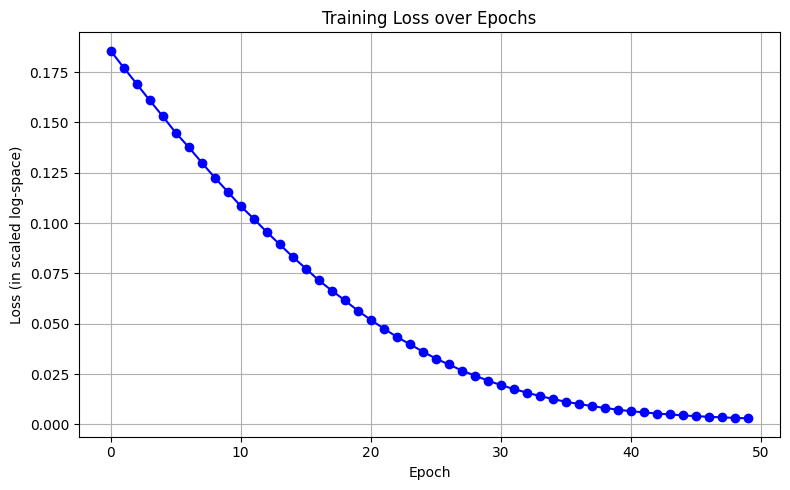

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
pred [[0.19159841]
 [0.27063505]
 [0.33621301]
 [0.40179097]
 [0.46736893]
 [0.53294689]
 [0.59821395]
 [0.65660806]
 [0.71500218]
 [0.77339629]
 [0.8317904 ]
 [0.89018452]
 [0.94857863]
 [1.00697274]
 [1.06536686]
 [1.12376097]
 [1.18215508]
 [1.24054919]
 [1.29894331]
 [1.35733742]]


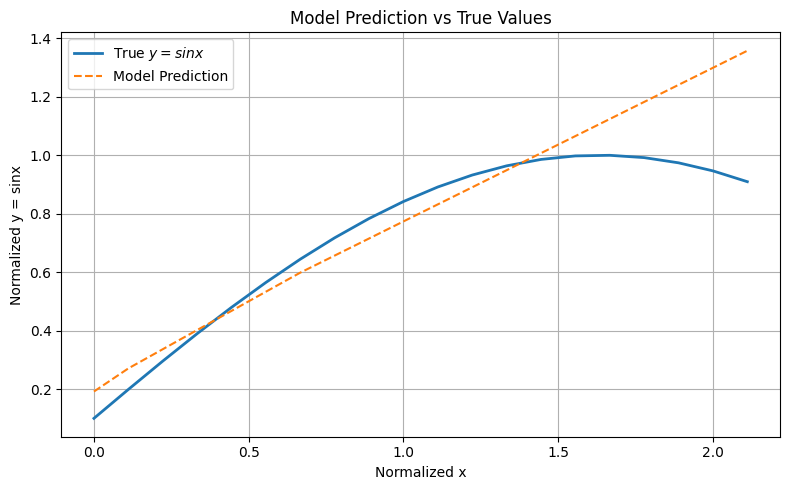

In [ ]:
from tensorflow.keras.losses import MeanSquaredError  # Import the MSE loss function



mse_loss = MeanSquaredError()
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.float64),
    tf.keras.layers.Dense(units=8,dtype=tf.float64,activation='relu'),
    tf.keras.layers.Dense(units=8,dtype=tf.float64,activation='relu'), #dtype necessary
    tf.keras.layers.Dense(units=1,dtype=tf.float64,activation=None)
])
model.compile(optimizer='adam', loss=mse_loss)
model.summary()
"""for layer in model.layers:
    print(f"Layer {layer.name} input dtype:", layer.input_dtype)
    print(f"Layer {layer.name} output dtype:", layer.dtype)"""


x_train_fp=np.linspace(0.1, 1.0, 50).reshape(-1, 1)
y_train_fp = np.array([[2.0], [4.0], [6.0], [8.0], [10.0],[200.0]], dtype=np.float64)
def min_max_scaling(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

# Normalize x_train and y_train
x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
#y_train_fp_normalized = min_max_scaling(y_train_fp)
y_train_fp_normalized=np.array(tf.math.sin(x_train_fp))

#x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd,dtype=tf.float64)

#y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd,dtype=tf.float64)

#print(x_train_fp_normalized,y_train_fp_normalized)

history=model.fit(x_train_fp_normalized, y_train_fp_normalized, epochs=50, verbose=2)
loss_values = history.history['loss']
#loss_values = [lns_to_float(l) for l in loss_values]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (in scaled log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

x_test_fp = np.linspace(0.1, 2, 20).reshape(-1, 1)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min)

# Convert to log-space
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)


prediction_log = model.predict(x_test_fp_normalized)
prediction_fp = lns_to_float(prediction_log)
print("pred",prediction_log)

true_y = np.array(tf.math.sin(x_test_fp))

# Plot predicted vs actual
plt.figure(figsize=(8, 5))
plt.plot(x_test_fp_normalized, true_y, label='True $y = sinx$', linewidth=2)
plt.plot(x_test_fp_normalized, prediction_log, label='Model Prediction', linestyle='--')
plt.title("Model Prediction vs True Values")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y = sinx")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Conclusion

Across all experiments, the **Log-Space Dense (LNS)** model consistently outperformed the corresponding **Keras Dense** model  on **non-linear** and **linear functions** .

### Key Findings:

- **Deeper loss reduction**: The LNS models reached **lower final losses** than its Keras counterpart, even when the latter was trained for **more epochs**.
- **Fewer epochs to converge**: LNS models required **fewer training epochs** to achieve good approximation.
- **Same memory footprint**: Both models in all the experiments had the same model size..
-  **Better validation generalization**: LNS models resembled the validation curve better, possibly due to their inherent **non-linearity and numerical stability**.

These results indicate that **logarithmic arithmetic in neural layers** can offer ** advantages in both efficiency and performance**. Hence, this shows a strong reason for further research into the adaption of LNS in deep learning models together with the development of LNS hardware.

